# 15. 감소위험 분류모델 테스트 (GTX-A, 역 권역 단위 검증)

**목적**: GTX-B·C 적용을 위한 '감소위험 분류모델'이 현재 GTX-A 변수만으로 **학습하지 않은 역 권역에 일반화되는지** 실제로 확인한다. 설계 문서는 `../감소위험_분류모델_설계.md`.

| 항목 | 설정 |
|---|---|
| 분석 단위 | 250m 셀 × 노선, 평일 07:00~09:59, 2024년 승차 > 0 (186쌍) |
| target | **T1** 단순 감소 (2025 < 2024) / **T2** 10% 이상 감소 (변화율 ≤ −10%) / **T3** 큰 감소 (변화율 하위 25%, 경계값은 **학습 fold에서만** 계산) |
| feature | log(보행시간), IC 도로거리, log(1+2024 승차), 20~50대 인구, 건축물 수, 경쟁 목적지 비율 (모두 개통 전 정보) |
| 모델 | Logistic(규제 없음), Ridge Logistic(L2, C=1), ElasticNet Logistic(l1_ratio=0.5, C=1) / 비교용 Random Forest(깊이 3), XGBoost(깊이 2) |
| 검증 | **leave-one-station-out**: 운정+킨텍스→대곡, 운정+대곡→킨텍스, 킨텍스+대곡→운정 |
| 분류 임계값 | **학습 fold의 양성 비율** (예측확률이 학습 데이터 평균 위험보다 높으면 '위험'). 0.5를 쓰면 불균형 target에서 한쪽으로만 예측되기 때문 |
| 지표 | ROC-AUC, PR-AUC(평균정밀도), Accuracy, Precision, Recall, F1, Brier, **Brier skill**(학습 양성비율만 쓰는 무정보 예측 대비 개선, >0이어야 의미 있음) |

선형 모델은 표준화(StandardScaler) 후 적합한다. 규제 강도는 표본이 작아 내부 튜닝 없이 C=1로 고정했다.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # 정리본 최상위의 config.py

from config import *
setup_notebook()

import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score, precision_score,
                             recall_score, f1_score, brier_score_loss)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
data = load_model_data()
data["log_walk"] = np.log(data["walk_min"])
trips = load_trips().dropna(subset=["셀 ID"])
pairs = (trips[trips["시"].between(*MORNING_HOURS)]
         .pivot_table(index=["셀 ID", "노선"], columns="연도", values="승차인원", aggfunc="sum", fill_value=0)
         .reset_index().rename(columns={2024: "y2024", 2025: "y2025"}))
pairs["셀 ID"] = pairs["셀 ID"].astype(int)
pairs = pairs.merge(data[["셀 ID", "nearest_station", "log_walk", "ic_access", "pop_20_50", "buildings", "competing_share"]], on="셀 ID")
pairs = pairs[pairs.y2024 > 0].reset_index(drop=True)
pairs["log_base"] = np.log1p(pairs.y2024)
pairs["rate"] = pairs.y2025 / pairs.y2024 - 1

STATIONS = ["대곡", "킨텍스", "운정중앙"]  # fold 이름 = 검증(제외) 권역
FEATURES = {
    "전체6": ["log_walk", "ic_access", "log_base", "pop_20_50", "buildings", "competing_share"],
    "핵심2 (보행+IC)": ["log_walk", "ic_access"],
    "핵심2+승차": ["log_walk", "ic_access", "log_base"],
    "핵심2+인구·건축물": ["log_walk", "ic_access", "pop_20_50", "buildings"],
    "핵심2+경쟁목적지": ["log_walk", "ic_access", "competing_share"],
    "전체6−승차": ["log_walk", "ic_access", "pop_20_50", "buildings", "competing_share"],
}
MODELS = {
    "Logistic": lambda: make_pipeline(StandardScaler(), LogisticRegression(penalty=None, max_iter=5000)),
    "Ridge": lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000)),
    "ElasticNet": lambda: make_pipeline(StandardScaler(), LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5, C=1.0, max_iter=20000)),
    "RandomForest": lambda: RandomForestClassifier(n_estimators=500, max_depth=3, min_samples_leaf=5, random_state=0),
    "XGBoost": lambda: XGBClassifier(n_estimators=200, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=0, verbosity=0),
}
print(f"셀×노선 {len(pairs)}쌍 | 권역별:", pairs.groupby("nearest_station").size().to_dict())

셀×노선 186쌍 | 권역별: {'대곡': 54, '운정중앙': 96, '킨텍스': 36}


In [2]:
def make_target(name, train_rate, test_rate):
    if name == "T1 단순 감소":
        return (train_rate < 0).astype(int), (test_rate < 0).astype(int)
    if name == "T2 10% 이상 감소":
        return (train_rate <= -0.10).astype(int), (test_rate <= -0.10).astype(int)
    cut = train_rate.quantile(0.25)  # 학습 fold에서만 계산 (검증 권역 정보 누설 방지)
    return (train_rate <= cut).astype(int), (test_rate <= cut).astype(int)


TARGETS = ["T1 단순 감소", "T2 10% 이상 감소", "T3 하위 25%"]


def fit_model(model_name, X, y, weight):
    model = MODELS[model_name]()
    if weight is None:
        return model.fit(X, y)
    if model_name in ("RandomForest", "XGBoost"):
        return model.fit(X, y, sample_weight=weight)
    return model.fit(X, y, logisticregression__sample_weight=weight)


def evaluate(target, features, model_name, frame=None, weighted=False):
    """leave-one-station-out. weighted=True면 학습·평가 모두 2024 승차인원 가중 (승객 기준)."""
    frame = pairs if frame is None else frame
    rows, oof = [], []
    for station in STATIONS:
        train, test = frame[frame.nearest_station != station], frame[frame.nearest_station == station]
        y_train, y_test = make_target(target, train.rate, test.rate)
        w_train = (train.y2024 / train.y2024.mean()).values if weighted else None  # 평균 1로 정규화 (규제 강도 유지)
        w_test = test.y2024.values if weighted else None
        model = fit_model(model_name, train[features], y_train, w_train)
        prob = model.predict_proba(test[features])[:, 1]
        prevalence = np.average(y_train, weights=w_train)
        pred = (prob >= prevalence).astype(int)
        both = y_test.nunique() > 1
        brier = brier_score_loss(y_test, prob, sample_weight=w_test)
        brier_ref = brier_score_loss(y_test, np.full(len(y_test), prevalence), sample_weight=w_test)
        rows.append({"검증 권역": station, "학습 n": len(train), "학습 양성": int(y_train.sum()), "학습 음성": int((1 - y_train).sum()),
                     "검증 n": len(test), "검증 양성": int(y_test.sum()), "검증 음성": int((1 - y_test).sum()),
                     "ROC-AUC": roc_auc_score(y_test, prob, sample_weight=w_test) if both else np.nan,
                     "PR-AUC": average_precision_score(y_test, prob, sample_weight=w_test) if both else np.nan,
                     "PR 기준선(양성비율)": np.average(y_test, weights=w_test),
                     "Accuracy": accuracy_score(y_test, pred, sample_weight=w_test),
                     "Precision": precision_score(y_test, pred, sample_weight=w_test, zero_division=0),
                     "Recall": recall_score(y_test, pred, sample_weight=w_test, zero_division=0),
                     "F1": f1_score(y_test, pred, sample_weight=w_test, zero_division=0),
                     "Brier": brier, "Brier skill": 1 - brier / brier_ref})
        oof.append(pd.DataFrame({"y": y_test.values, "p": prob, "w": w_test if weighted else 1.0, "station": station}))
    folds = pd.DataFrame(rows)
    mean = folds.drop(columns=["검증 권역"]).mean(numeric_only=True)
    mean["검증 권역"] = "평균"
    return pd.concat([folds, mean.to_frame().T], ignore_index=True), pd.concat(oof, ignore_index=True)


METRICS = ["ROC-AUC", "PR-AUC", "PR 기준선(양성비율)", "Accuracy", "Precision", "Recall", "F1", "Brier", "Brier skill"]

## 1. target별 클래스 비율 (불균형 점검)

In [3]:
rows = []
for station in ["전체"] + STATIONS:
    sub = pairs if station == "전체" else pairs[pairs.nearest_station == station]
    rows.append({"권역": station, "n": len(sub),
                 "T1 양성비율": (sub.rate < 0).mean(), "T2 양성비율": (sub.rate <= -0.10).mean(),
                 "T3 양성비율 (전체 하위25% 기준)": (sub.rate <= pairs.rate.quantile(0.25)).mean(),
                 "변화율 0% (변화 없음) 쌍": int((sub.rate == 0).sum()), "2024 승차 <5 쌍": int((sub.y2024 < 5).sum())})
pd.DataFrame(rows).round(3)

,권역,n,T1 양성비율,T2 양성비율,T3 양성비율 (전체 하위25% 기준),변화율 0% (변화 없음) 쌍,2024 승차 <5 쌍
0,전체,186,0.656,0.634,0.253,5,27
1,대곡,54,0.537,0.519,0.241,1,13
2,킨텍스,36,0.722,0.722,0.111,1,3
3,운정중앙,96,0.698,0.667,0.312,3,11


**해석**
- T1·T2는 양성(감소)이 63~66%로 **오히려 다수 클래스**다. 심한 불균형은 아니지만, 무조건 '감소'라고 찍어도 Accuracy가 0.65 가까이 나온다. 그래서 **Accuracy는 의미가 없다.**
- T3는 정의상 약 25%다. 하지만 권역별로 **킨텍스 11%(36쌍 중 4쌍)**처럼 크게 다르고, 킨텍스를 검증 권역으로 쓸 때 양성이 3개뿐이라 지표가 불안정하다.
- **권역별 기본 감소율이 다르다**: 대곡은 T2 52%, 킨텍스는 72%다. 학습 권역의 평균 위험이 검증 권역에 그대로 맞지 않는다(base-rate shift). B·C에서도 똑같이 생길 문제다.
- 2024년 승차 5명 미만 쌍이 27개(15%)다. 이 쌍들의 '감소' 라벨은 대부분 우연이다.

## 2. 본 비교: target × 모델 (feature = 전체6, 가중치 없음)
요청 사양 그대로의 결과다. 각 표에서 '평균' 행이 3개 fold의 평균이다.

In [4]:
main_rows, oofs = [], {}
for target in TARGETS:
    for model_name in MODELS:
        folds, oof = evaluate(target, FEATURES["전체6"], model_name)
        folds.insert(0, "모델", model_name)
        folds.insert(0, "target", target)
        main_rows.append(folds)
        oofs[(target, model_name)] = oof
main = pd.concat(main_rows, ignore_index=True)
for target in TARGETS:
    print(f"\n===== {target} =====")
    display(main[main.target == target].drop(columns="target").round(3))


===== T1 단순 감소 =====


,모델,검증 권역,학습 n,학습 양성,학습 음성,검증 n,검증 양성,검증 음성,ROC-AUC,PR-AUC,PR 기준선(양성비율),Accuracy,Precision,Recall,F1,Brier,Brier skill
0,Logistic,대곡,132,93,39,54,29,25,0.451724,0.562499,0.537037,0.462963,0.5,0.206897,0.292683,0.278315,-0.005881
1,Logistic,킨텍스,150,96,54,36,26,10,0.626923,0.835849,0.722222,0.638889,0.740741,0.769231,0.754717,0.19205,0.073913
2,Logistic,운정중앙,90,55,35,96,67,29,0.523932,0.67979,0.697917,0.71875,0.722222,0.970149,0.828025,0.216864,0.006871
3,Logistic,평균,124.0,81.333333,42.666667,62.0,40.666667,21.333333,0.534193,0.692713,0.652392,0.606867,0.654321,0.648759,0.625142,0.229076,0.024968
4,Ridge,대곡,132,93,39,54,29,25,0.43931,0.543094,0.537037,0.462963,0.5,0.241379,0.325581,0.279181,-0.009012
5,Ridge,킨텍스,150,96,54,36,26,10,0.626923,0.836105,0.722222,0.638889,0.740741,0.769231,0.754717,0.191443,0.07684
6,Ridge,운정중앙,90,55,35,96,67,29,0.510551,0.672796,0.697917,0.708333,0.714286,0.970149,0.822785,0.218242,0.000561
7,Ridge,평균,124.0,81.333333,42.666667,62.0,40.666667,21.333333,0.525595,0.683998,0.652392,0.603395,0.651675,0.660253,0.634361,0.229622,0.022796
8,ElasticNet,대곡,132,93,39,54,29,25,0.435172,0.538312,0.537037,0.481481,0.533333,0.275862,0.363636,0.281419,-0.017103
9,ElasticNet,킨텍스,150,96,54,36,26,10,0.626923,0.836464,0.722222,0.638889,0.740741,0.769231,0.754717,0.190867,0.079616



===== T2 10% 이상 감소 =====


,모델,검증 권역,학습 n,학습 양성,학습 음성,검증 n,검증 양성,검증 음성,ROC-AUC,PR-AUC,PR 기준선(양성비율),Accuracy,Precision,Recall,F1,Brier,Brier skill
20,Logistic,대곡,132,90,42,54,28,26,0.456731,0.512833,0.518519,0.481481,0.5,0.142857,0.222222,0.277759,-0.005193
21,Logistic,킨텍스,150,92,58,36,26,10,0.638462,0.84727,0.722222,0.611111,0.730769,0.730769,0.730769,0.194553,0.084344
22,Logistic,운정중앙,90,54,36,96,64,32,0.537598,0.652555,0.666667,0.6875,0.688889,0.96875,0.805195,0.229452,-0.012289
23,Logistic,평균,124.0,78.666667,45.333333,62.0,39.333333,22.666667,0.544263,0.670886,0.635802,0.593364,0.639886,0.614125,0.586062,0.233921,0.022288
24,Ridge,대곡,132,90,42,54,28,26,0.451236,0.50228,0.518519,0.462963,0.444444,0.142857,0.216216,0.277984,-0.006009
25,Ridge,킨텍스,150,92,58,36,26,10,0.646154,0.851236,0.722222,0.611111,0.730769,0.730769,0.730769,0.194123,0.086368
26,Ridge,운정중앙,90,54,36,96,64,32,0.521973,0.645981,0.666667,0.6875,0.688889,0.96875,0.805195,0.230265,-0.015874
27,Ridge,평균,124.0,78.666667,45.333333,62.0,39.333333,22.666667,0.539788,0.666499,0.635802,0.587191,0.621368,0.614125,0.58406,0.234124,0.021495
28,ElasticNet,대곡,132,90,42,54,28,26,0.445742,0.495787,0.518519,0.462963,0.444444,0.142857,0.216216,0.278991,-0.009652
29,ElasticNet,킨텍스,150,92,58,36,26,10,0.646154,0.851236,0.722222,0.611111,0.730769,0.730769,0.730769,0.193797,0.087901



===== T3 하위 25% =====


,모델,검증 권역,학습 n,학습 양성,학습 음성,검증 n,검증 양성,검증 음성,ROC-AUC,PR-AUC,PR 기준선(양성비율),Accuracy,Precision,Recall,F1,Brier,Brier skill
40,Logistic,대곡,132,33,99,54,13,41,0.663227,0.370397,0.240741,0.62963,0.315789,0.461538,0.375,0.174677,0.044805
41,Logistic,킨텍스,150,38,112,36,3,33,0.585859,0.205556,0.083333,0.75,0.2,0.666667,0.307692,0.104027,0.011989
42,Logistic,운정중앙,90,23,67,96,35,61,0.492272,0.357777,0.364583,0.53125,0.34375,0.314286,0.328358,0.289876,-0.190216
43,Logistic,평균,124.0,31.333333,92.666667,62.0,17.0,45.0,0.580452,0.311243,0.229552,0.63696,0.286513,0.48083,0.337017,0.189527,-0.044474
44,Ridge,대곡,132,33,99,54,13,41,0.665103,0.371313,0.240741,0.611111,0.3,0.461538,0.363636,0.174496,0.045793
45,Ridge,킨텍스,150,38,112,36,3,33,0.585859,0.205556,0.083333,0.75,0.2,0.666667,0.307692,0.102244,0.02892
46,Ridge,운정중앙,90,23,67,96,35,61,0.490867,0.357815,0.364583,0.53125,0.34375,0.314286,0.328358,0.28564,-0.172822
47,Ridge,평균,124.0,31.333333,92.666667,62.0,17.0,45.0,0.580609,0.311561,0.229552,0.630787,0.28125,0.48083,0.333229,0.18746,-0.032703
48,ElasticNet,대곡,132,33,99,54,13,41,0.670732,0.391804,0.240741,0.62963,0.333333,0.538462,0.411765,0.174283,0.046957
49,ElasticNet,킨텍스,150,38,112,36,3,33,0.585859,0.205556,0.083333,0.75,0.2,0.666667,0.307692,0.100687,0.043712


In [5]:
summary = main[main["검증 권역"] == "평균"].pivot_table(index="모델", columns="target", values=["ROC-AUC", "PR-AUC", "Brier skill"])
summary.round(3)

Brier skill                           PR-AUC                          ROC-AUC                       
target          T1 단순 감소 T2 10% 이상 감소 T3 하위 25%  T1 단순 감소 T2 10% 이상 감소 T3 하위 25%  T1 단순 감소 T2 10% 이상 감소 T3 하위 25%
모델                                                                                                               
ElasticNet      0.020646     0.021675 -0.019197  0.680336     0.662883  0.318825  0.521299     0.537142  0.583578
Logistic        0.024968     0.022288 -0.044474  0.692713     0.670886  0.311243  0.534193     0.544263  0.580452
RandomForest      0.0072     0.008133   0.01414  0.694988     0.670484   0.35317  0.477551     0.485553  0.583765
Ridge           0.022796     0.021495 -0.032703  0.683998     0.666499  0.311561  0.525595     0.539788  0.580609
XGBoost        -0.104008    -0.084031 -0.012295  0.735598       0.7001  0.399488  0.521843     0.528384  0.620574

**해석 (요청 사양 그대로: 전체 6변수, 가중치 없음)**
- **모든 target × 모델에서 ROC-AUC 0.48~0.62, Brier skill은 0 근처이거나 음수**다. 학습하지 않은 권역에 대해 **사실상 예측력이 없다.**
- fold별로도 일관성이 없다. 같은 모델이 어떤 권역에서는 0.63, 다른 권역에서는 0.44가 나온다.
- RandomForest·XGBoost는 선형 모델보다 낫지 않다. XGBoost는 Brier skill이 가장 나쁘다(과적합).
- T3의 XGBoost 평균 AUC 0.62가 가장 높아 보이지만, Brier skill이 음수이고 킨텍스 fold 양성이 3개라 믿을 수 없다.

## 3. 변수 넣고 빼기 (선형 3모델, 가중치 없음)

In [6]:
rows = []
for target in TARGETS:
    for fs_name, cols in FEATURES.items():
        for model_name in ["Logistic", "Ridge", "ElasticNet"]:
            folds, _ = evaluate(target, cols, model_name)
            m = folds[folds["검증 권역"] == "평균"].iloc[0]
            fold_auc = folds[folds["검증 권역"] != "평균"].set_index("검증 권역")["ROC-AUC"]
            rows.append({"target": target, "변수": fs_name, "모델": model_name, "평균 ROC-AUC": m["ROC-AUC"],
                         **{f"AUC {s}": fold_auc[s] for s in STATIONS}, "평균 PR-AUC": m["PR-AUC"], "Brier skill": m["Brier skill"]})
ablation = pd.DataFrame(rows)
ablation.pivot_table(index=["target", "변수"], columns="모델", values="평균 ROC-AUC").round(3)

모델                        ElasticNet  Logistic  Ridge
target       변수                                      
T1 단순 감소     전체6               0.521     0.534  0.526
             전체6−승차            0.417     0.427  0.422
             핵심2 (보행+IC)       0.420     0.428  0.422
             핵심2+경쟁목적지         0.423     0.429  0.425
             핵심2+승차            0.506     0.508  0.505
             핵심2+인구·건축물        0.428     0.445  0.437
T2 10% 이상 감소 전체6               0.537     0.544  0.540
             전체6−승차            0.456     0.461  0.459
             핵심2 (보행+IC)       0.430     0.443  0.438
             핵심2+경쟁목적지         0.450     0.456  0.454
             핵심2+승차            0.511     0.508  0.508
             핵심2+인구·건축물        0.438     0.447  0.441
T3 하위 25%    전체6               0.584     0.580  0.581
             전체6−승차            0.477     0.505  0.501
             핵심2 (보행+IC)       0.571     0.581  0.580
             핵심2+경쟁목적지         0.557     0.552  0.553
             핵심2+승차            0.656     0.649  0.652
             핵심2+인구·건축물        0.517     0.512  0.510

In [7]:
# 요청한 비교를 직접 대조 (Ridge 기준, 평균 ROC-AUC 차이)
ridge = ablation[ablation.모델 == "Ridge"].set_index(["target", "변수"])["평균 ROC-AUC"]
comparisons = [("2024 승차 넣음 vs 뺌", "전체6", "전체6−승차"), ("2024 승차 추가 효과 (핵심2 기준)", "핵심2+승차", "핵심2 (보행+IC)"),
               ("인구·건축물 추가 효과", "핵심2+인구·건축물", "핵심2 (보행+IC)"), ("경쟁목적지 추가 효과", "핵심2+경쟁목적지", "핵심2 (보행+IC)")]
pd.DataFrame({target: {label: ridge[(target, a)] - ridge[(target, b)] for label, a, b in comparisons} for target in TARGETS}).round(3)

,T1 단순 감소,T2 10% 이상 감소,T3 하위 25%
2024 승차 넣음 vs 뺌,0.104,0.081,0.080
2024 승차 추가 효과 (핵심2 기준),0.083,0.070,0.072
인구·건축물 추가 효과,0.015,0.003,-0.070
경쟁목적지 추가 효과,0.004,0.016,-0.027


**해석 (가중치 없음 기준)**
- **2024년 승차를 넣으면 AUC가 0.07~0.10 오른다.** 하지만 이건 GTX 효과가 아니라 **라벨 잡음의 구조**를 맞히는 것이다. 승차가 적은 쌍일수록 1~2명 차이로 '감소'가 되거나 '증가'가 되기 때문이다. 아래 4번처럼 승객 가중을 하면 이 효과는 사라지거나 오히려 해가 된다.
- **인구·건축물**: 개선 없음(T1 +0.015, T2 +0.003, T3 −0.070).
- **현재 정의의 경쟁 목적지 비율**: 개선 없음(T1 +0.004, T2 +0.016, T3 −0.027).
- 가중치 없이 핵심2만 쓰면 T1·T2 AUC가 **0.42~0.44로 0.5보다 낮다.** 영향요인 모형에서 확인한 것과 같다. 승차가 적은 쌍에서는 방향이 반대로 나온다.

## 4. 왜 낮은가: 라벨 잡음 진단 — 승객 가중 / 소규모 쌍 제외

하루치 데이터에서 승차 1~4명짜리 쌍의 '감소' 라벨은 대부분 우연이다(예: 2명 → 1명 = −50%). 영향요인 모형(Poisson)은 승객 수로 가중되어 이 잡음에 덜 흔들렸지만, 분류모델은 모든 쌍을 똑같이 센다.
두 가지 처리를 비교한다.
- **승객 가중**: 학습과 평가 모두 2024 승차인원을 가중치로 쓴다 (평가지표 = "승객 기준" AUC)
- **소규모 쌍 제외**: 2024 승차 ≥ 5, 10, 20명인 쌍만 쓴다

In [8]:
rows = []
for min_base in (1, 5, 10, 20):
    frame = pairs[pairs.y2024 >= min_base]
    for weighted in (False, True):
        for target in TARGETS:
            for fs_name in ["핵심2 (보행+IC)", "핵심2+승차", "전체6"]:
                folds, _ = evaluate(target, FEATURES[fs_name], "Ridge", frame=frame, weighted=weighted)
                fold_auc = folds[folds["검증 권역"] != "평균"].set_index("검증 권역")
                m = folds[folds["검증 권역"] == "평균"].iloc[0]
                rows.append({"2024 승차 ≥": min_base, "가중": "승객 가중" if weighted else "없음", "target": target, "변수": fs_name,
                             "n": len(frame), "평균 ROC-AUC": m["ROC-AUC"],
                             **{f"AUC {s}": fold_auc.loc[s, "ROC-AUC"] for s in STATIONS},
                             f"{STATIONS[0]} 검증 양성/음성": f"{int(fold_auc.loc[STATIONS[0], '검증 양성'])}/{int(fold_auc.loc[STATIONS[0], '검증 음성'])}",
                             "Brier skill": m["Brier skill"]})
noise = pd.DataFrame(rows)
noise.pivot_table(index=["target", "변수"], columns=["2024 승차 ≥", "가중"], values="평균 ROC-AUC").round(2)

2024 승차 ≥                   1           5           10          20      
가중                       승객 가중    없음 승객 가중    없음 승객 가중    없음 승객 가중    없음
target       변수                                                         
T1 단순 감소     전체6          0.50  0.53  0.50  0.52  0.53  0.56  0.51  0.55
             핵심2 (보행+IC)  0.61  0.42  0.62  0.51  0.63  0.57  0.66  0.63
             핵심2+승차       0.62  0.50  0.62  0.52  0.63  0.58  0.61  0.61
T2 10% 이상 감소 전체6          0.54  0.54  0.54  0.52  0.56  0.58  0.63  0.62
             핵심2 (보행+IC)  0.63  0.44  0.65  0.51  0.68  0.58  0.74  0.66
             핵심2+승차       0.57  0.51  0.58  0.52  0.59  0.60  0.65  0.62
T3 하위 25%    전체6          0.61  0.58  0.49  0.47  0.60  0.57  0.77  0.62
             핵심2 (보행+IC)  0.74  0.58  0.63  0.56  0.66  0.49  0.74  0.35
             핵심2+승차       0.72  0.65  0.59  0.59  0.57  0.50  0.70  0.31

In [9]:
# fold별로 보면 (T2, 핵심2) — 가장 일관된 조합 확인
noise[(noise.target == "T2 10% 이상 감소") & (noise.변수 == "핵심2 (보행+IC)")].round(3)

,2024 승차 ≥,가중,target,변수,n,평균 ROC-AUC,AUC 대곡,AUC 킨텍스,AUC 운정중앙,대곡 검증 양성/음성,Brier skill
3,1,없음,T2 10% 이상 감소,핵심2 (보행+IC),186,0.438,0.333,0.529,0.451,28/26,-0.024
12,1,승객 가중,T2 10% 이상 감소,핵심2 (보행+IC),186,0.633,0.599,0.625,0.676,28/26,0.096
21,5,없음,T2 10% 이상 감소,핵심2 (보행+IC),159,0.506,0.385,0.555,0.578,20/21,0.029
30,5,승객 가중,T2 10% 이상 감소,핵심2 (보행+IC),159,0.652,0.636,0.630,0.689,20/21,0.100
39,10,없음,T2 10% 이상 감소,핵심2 (보행+IC),128,0.578,0.519,0.520,0.695,14/15,0.086
48,10,승객 가중,T2 10% 이상 감소,핵심2 (보행+IC),128,0.675,0.630,0.686,0.710,14/15,0.114
57,20,없음,T2 10% 이상 감소,핵심2 (보행+IC),87,0.658,0.759,0.545,0.670,7/8,0.041
66,20,승객 가중,T2 10% 이상 감소,핵심2 (보행+IC),87,0.735,0.823,0.646,0.737,7/8,0.078


**해석: 성능이 낮은 핵심 원인은 '라벨 잡음'이다**
- **승객 가중**을 하면 T1·T2에서 핵심2(보행+IC)의 AUC가 0.42~0.44 → **0.61~0.63**으로 오르고, **세 fold 모두 0.6~0.68로 일관된다.**
- 승차가 적은 쌍을 빼도 비슷하게 좋아진다(T2: ≥10명 0.58, ≥20명 0.66). 둘 다 하면(≥20명 + 가중) 0.74까지 오른다. 하지만 그때 대곡 검증 쌍은 15개(양성 7)뿐이라 믿기 어렵다.
- 가중을 하면 2024 승차, 인구, 건축물, 경쟁 목적지를 더하는 게 **오히려 성능을 떨어뜨린다.** 변수가 적을수록 권역 간 이전이 잘 된다.
- → 분류모델도 **"승객 기준"**으로 설계해야 한다. 학습은 2024 승차 가중으로, 평가도 승객 가중 AUC로 한다. 영향요인 모형(Poisson)이 승객 가중이었던 것과 같은 논리다.

## 5. 후보 설정의 전체 지표 (승객 가중, 186쌍)

In [10]:
rows = []
for target in TARGETS:
    for model_name in MODELS:
        folds, _ = evaluate(target, FEATURES["핵심2 (보행+IC)"], model_name, weighted=True)
        folds.insert(0, "모델", model_name)
        folds.insert(0, "target", target)
        rows.append(folds)
weighted_table = pd.concat(rows, ignore_index=True)
display(weighted_table[weighted_table["검증 권역"] == "평균"].drop(columns=["검증 권역"]).round(3))
print("T2 · 핵심2 · 승객 가중 — fold별 전체 지표")
weighted_table[(weighted_table.target == "T2 10% 이상 감소")].round(3)

,target,모델,학습 n,학습 양성,학습 음성,검증 n,검증 양성,검증 음성,ROC-AUC,PR-AUC,PR 기준선(양성비율),Accuracy,Precision,Recall,F1,Brier,Brier skill
3,T1 단순 감소,Logistic,124.0,81.333333,42.666667,62.0,40.666667,21.333333,0.618832,0.795498,0.713214,0.662239,0.84865,0.631071,0.620203,0.195125,0.082004
7,T1 단순 감소,Ridge,124.0,81.333333,42.666667,62.0,40.666667,21.333333,0.614843,0.79494,0.713214,0.658006,0.84595,0.622467,0.610589,0.196777,0.077397
11,T1 단순 감소,ElasticNet,124.0,81.333333,42.666667,62.0,40.666667,21.333333,0.60258,0.786869,0.713214,0.658006,0.84595,0.622467,0.610589,0.197701,0.074435
15,T1 단순 감소,RandomForest,124.0,81.333333,42.666667,62.0,40.666667,21.333333,0.586878,0.781943,0.713214,0.542393,0.910721,0.38625,0.508028,0.207799,0.015927
19,T1 단순 감소,XGBoost,124.0,81.333333,42.666667,62.0,40.666667,21.333333,0.491187,0.708894,0.713214,0.552546,0.694844,0.575088,0.623405,0.226696,-0.060615
23,T2 10% 이상 감소,Logistic,124.0,78.666667,45.333333,62.0,39.333333,22.666667,0.640737,0.768778,0.661804,0.678919,0.848221,0.590308,0.610299,0.213502,0.102428
27,T2 10% 이상 감소,Ridge,124.0,78.666667,45.333333,62.0,39.333333,22.666667,0.633218,0.763553,0.661804,0.670412,0.844069,0.574548,0.595067,0.216403,0.096414
31,T2 10% 이상 감소,ElasticNet,124.0,78.666667,45.333333,62.0,39.333333,22.666667,0.618925,0.753448,0.661804,0.670538,0.844095,0.574706,0.595153,0.218257,0.09142
35,T2 10% 이상 감소,RandomForest,124.0,78.666667,45.333333,62.0,39.333333,22.666667,0.577568,0.746053,0.661804,0.573971,0.893936,0.362366,0.461355,0.228897,0.044211
39,T2 10% 이상 감소,XGBoost,124.0,78.666667,45.333333,62.0,39.333333,22.666667,0.535324,0.692385,0.661804,0.566448,0.628854,0.528515,0.568317,0.239264,0.008883


T2 · 핵심2 · 승객 가중 — fold별 전체 지표


,target,모델,검증 권역,학습 n,학습 양성,학습 음성,검증 n,검증 양성,검증 음성,ROC-AUC,PR-AUC,PR 기준선(양성비율),Accuracy,Precision,Recall,F1,Brier,Brier skill
20,T2 10% 이상 감소,Logistic,대곡,132,90,42,54,28,26,0.621021,0.586174,0.427403,0.618609,0.941176,0.114833,0.204691,0.295684,0.19836
21,T2 10% 이상 감소,Logistic,킨텍스,150,92,58,36,26,10,0.624902,0.858953,0.764413,0.648279,0.787074,0.740098,0.762864,0.17461,0.055661
22,T2 10% 이상 감소,Logistic,운정중앙,90,54,36,96,64,32,0.676289,0.861205,0.793597,0.769868,0.816413,0.915994,0.863342,0.170212,0.053262
23,T2 10% 이상 감소,Logistic,평균,124.0,78.666667,45.333333,62.0,39.333333,22.666667,0.640737,0.768778,0.661804,0.678919,0.848221,0.590308,0.610299,0.213502,0.102428
24,T2 10% 이상 감소,Ridge,대곡,132,90,42,54,28,26,0.598669,0.570984,0.427403,0.610429,0.930233,0.095694,0.173536,0.306352,0.169437
25,T2 10% 이상 감소,Ridge,킨텍스,150,92,58,36,26,10,0.624902,0.858928,0.764413,0.635836,0.783324,0.72382,0.752397,0.174372,0.056948
26,T2 10% 이상 감소,Ridge,운정중앙,90,54,36,96,64,32,0.676083,0.860747,0.793597,0.764972,0.818651,0.904129,0.859269,0.168487,0.062858
27,T2 10% 이상 감소,Ridge,평균,124.0,78.666667,45.333333,62.0,39.333333,22.666667,0.633218,0.763553,0.661804,0.670412,0.844069,0.574548,0.595067,0.216403,0.096414
28,T2 10% 이상 감소,ElasticNet,대곡,132,90,42,54,28,26,0.554539,0.539814,0.427403,0.610429,0.930233,0.095694,0.173536,0.311947,0.154268
29,T2 10% 이상 감소,ElasticNet,킨텍스,150,92,58,36,26,10,0.624902,0.858953,0.764413,0.635836,0.783324,0.72382,0.752397,0.174386,0.056871


## 6. 평가 불안정성: fold별 ROC-AUC 부트스트랩 95% 구간

In [11]:
def bootstrap_auc(oof, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    out = {}
    for station, g in oof.groupby("station"):
        values = []
        for _ in range(n):
            idx = rng.integers(0, len(g), len(g))
            s = g.iloc[idx]
            if s.y.nunique() > 1:
                values.append(roc_auc_score(s.y, s.p, sample_weight=s.w))
        out[station] = {"n": len(g), "양성": int(g.y.sum()), "AUC": roc_auc_score(g.y, g.p, sample_weight=g.w),
                        "95% 하한": np.percentile(values, 2.5), "95% 상한": np.percentile(values, 97.5)}
    return pd.DataFrame(out).T


rows = []
for label, weighted in [("가중 없음", False), ("승객 가중", True)]:
    _, oof = evaluate("T2 10% 이상 감소", FEATURES["핵심2 (보행+IC)"], "Ridge", weighted=weighted)
    table = bootstrap_auc(oof)
    table.insert(0, "설정", f"T2 · 핵심2 · Ridge · {label}")
    rows.append(table)
pd.concat(rows).round(3)

,설정,n,양성,AUC,95% 하한,95% 상한
대곡,T2 · 핵심2 · Ridge · 가중 없음,54.0,28.0,0.333,0.186,0.489
운정중앙,T2 · 핵심2 · Ridge · 가중 없음,96.0,64.0,0.451,0.320,0.580
킨텍스,T2 · 핵심2 · Ridge · 가중 없음,36.0,26.0,0.529,0.293,0.761
대곡,T2 · 핵심2 · Ridge · 승객 가중,54.0,28.0,0.599,0.376,0.770
운정중앙,T2 · 핵심2 · Ridge · 승객 가중,96.0,64.0,0.676,0.511,0.808
킨텍스,T2 · 핵심2 · Ridge · 승객 가중,36.0,26.0,0.625,0.315,0.852


**해석: 평가 자체가 불안정하다**
- 가장 나은 설정(T2 · 핵심2 · Ridge · 승객 가중)도 fold별 AUC 95% 구간이 **대곡 0.38~0.77, 킨텍스 0.32~0.85, 운정 0.51~0.81**이다. **하한이 0.5를 넘는 건 운정 하나뿐**이다.
- 검증 권역이 36~96쌍이고, 실제 독립 정보는 셀 수십 개와 역 3곳뿐이라 AUC 하나하나의 오차가 크다.
- fold가 3개라 '평균 AUC'의 신뢰구간은 사실상 계산할 수 없다. 권역을 늘려야 한다(예: GTX-A 동탄 구간 추가).

## 7. 보정(calibration): 예측 위험 vs 실제 감소 비율 (T2 · 핵심2 · Ridge · 승객 가중, 3개 fold 통합)

,쌍 수,평균 예측확률,실제 감소 비율(승객 가중)
예측 구간,,,
하위 25%,47.0,0.571,0.633
25~50%,46.0,0.688,0.564
50~75%,47.0,0.760,0.769
상위 25%,46.0,0.847,0.876


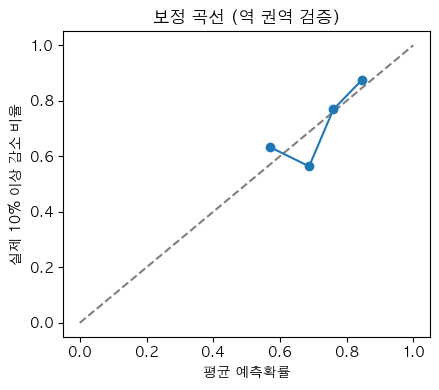

In [12]:
_, oof = evaluate("T2 10% 이상 감소", FEATURES["핵심2 (보행+IC)"], "Ridge", weighted=True)
oof["예측 구간"] = pd.qcut(oof.p, 4, labels=["하위 25%", "25~50%", "50~75%", "상위 25%"])
cal = oof.groupby("예측 구간", observed=True).apply(lambda g: pd.Series({
    "쌍 수": len(g), "평균 예측확률": np.average(g.p, weights=g.w), "실제 감소 비율(승객 가중)": np.average(g.y, weights=g.w)}))
display(cal.round(3))
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.plot(cal["평균 예측확률"], cal["실제 감소 비율(승객 가중)"], "o-")
ax.set_xlabel("평균 예측확률")
ax.set_ylabel("실제 10% 이상 감소 비율")
ax.set_title("보정 곡선 (역 권역 검증)")
plt.tight_layout()
plt.show()

**해석: 보정(calibration)**
- 3개 fold를 합쳐 예측확률 4분위로 보면, 실제 감소 비율이 하위 25%·25~50% 구간 0.56~0.63, 50~75% 0.77, 상위 25% 0.88이다. **위쪽 절반과 아래쪽 절반은 구분**되지만 아래 두 구간끼리는 순서가 뒤바뀐다.
- fold별로 보면 대곡의 실제 감소 비율(승객 기준 43%)이 학습 권역(약 79%)보다 훨씬 낮다. 그래서 '학습 평균 위험보다 높으면 위험'으로 자르면 대곡에서 **Recall이 0.10**까지 떨어진다(5번 표).
- → **절대 확률은 다른 권역으로 옮겨지지 않는다.** B·C에서는 확률값을 그대로 쓰지 말고, **해당 지역 안에서의 상대 순위(분위)로 등급**을 매겨야 한다.

## 8. 전체 A로 학습한 후보 모델의 계수 (방향 확인)

In [13]:
rows = {}
for target in TARGETS:
    y, _ = make_target(target, pairs.rate, pairs.rate)
    model = fit_model("Ridge", pairs[FEATURES["핵심2 (보행+IC)"]], y, (pairs.y2024 / pairs.y2024.mean()).values)
    rows[target] = dict(zip(["log 보행시간 (표준화 계수)", "IC 도로거리 (표준화 계수)"], model[-1].coef_[0]))
pd.DataFrame(rows).round(3)

,T1 단순 감소,T2 10% 이상 감소,T3 하위 25%
log 보행시간 (표준화 계수),-0.720,-0.794,0.252
IC 도로거리 (표준화 계수),0.711,0.869,0.362


**해석: 방향 점검**
- T1·T2에서는 **역에 가까울수록(log 보행시간 −), IC에서 멀수록(+) 감소위험이 높다.** 영향요인 모형(Poisson v2)과 같은 방향이다.
- **T3는 보행시간 계수가 +로 반대**다. 하위 25% 라벨은 '1명 → 0명(−100%)' 같은 소규모 쌍이 대부분을 차지해서, 실제 큰 감소와 잡음이 섞인다. → 현재 데이터로는 **T3를 쓰면 안 된다.**

---
## 최종 판단

### 1. 가장 안정적인 target: **T2 (10% 이상 감소)**
| target | 승객 가중 AUC (fold 범위) | 계수 방향 | 판단 |
|---|---|---|---|
| T1 단순 감소 | 0.61 (0.53~0.70) | 가설과 일치 | fold 간 편차가 크고(대곡 0.53), ±1명 같은 아주 작은 변화도 '감소'로 잡힌다 |
| **T2 10% 이상** | **0.63 (0.60~0.68)** | **가설과 일치** | fold 간 편차가 가장 작고, 작은 변화를 걸러낸다 → **채택** |
| T3 하위 25% | 0.74 (0.57~0.82) | **보행시간 반대** | 킨텍스 양성 3개, 소규모 쌍 잡음이 지배 → **현재 데이터로는 부적합** |

### 2. 가장 일반화 성능이 좋은 모델: **Logistic ≈ Ridge (승객 가중)**
- 변수가 2개라 규제 효과가 거의 없어서 둘의 결과가 같다. 변수를 늘릴 미래를 대비해 **Ridge를 메인**으로 둔다.
- ElasticNet은 Ridge와 비슷하거나 약간 낮다. RandomForest·XGBoost는 일관되게 더 나쁘다 → 비교용으로만 쓴다.

### 3. 가장 안정적인 변수 조합: **log(보행시간) + IC 도로거리**
- 2024 승차, 인구·건축물, 현재 정의의 경쟁 목적지 비율은 승객 가중 기준으로 **개선이 없거나 오히려 나빠진다.**

### 4. B·C에 감소위험 등급을 적용할 수 있는 수준인가? → **아직 아니다**
- 가장 좋은 설정의 평균 ROC-AUC가 **0.63**이다. 일반적인 '쓸 만함' 기준인 0.7에 못 미친다.
- fold 3개 중 2개는 **95% 구간이 0.5를 포함**한다(대곡 0.38~0.77, 킨텍스 0.32~0.85).
- 절대 확률은 권역 사이에서 맞지 않는다(대곡 Recall 0.10).
- → 지금 수준에서는 B·C 결과를 **"감소위험 등급"으로 발표하면 안 된다.** 할 수 있는 최대치는 영향요인 분석의 계수 방향(역 근접 + IC 원거리)을 쓴 **탐색적 상대 순위**이고, "검증된 예측모형"이 아니라고 명시해야 한다.

### 왜 낮은가
1. **라벨 잡음**: 연도별 하루치라 셀×노선 단위 감소 여부 자체가 불안정하다(승차 5명 미만이 15%).
2. **검증 단위가 3개뿐**: 역 권역 3곳으로는 일반화 성능을 안정적으로 추정할 수 없다.
3. **권역 간 기본 감소율 차이**(대곡 52% vs 킨텍스 72%)를 설명하는 변수가 없다. 대곡은 기존 3호선·경의중앙선 환승역이라는 점처럼, 철도 대안 여부가 빠져 있다.
4. **노선 수준 정보가 빠져 있다**: 영향요인 모형에서는 노선 FE가 설명력의 대부분(R²_D 0.35)을 맡았는데, 분류모델에서는 B·C로 옮길 수 없어서 뺐다. 그 자리를 채울 노선 특성 변수가 없다.

### 다음에 추가할 것 (우선순위)
1. **평일 여러 날 데이터** → 라벨 잡음 감소 (가장 큰 효과 예상)
2. **GTX-A 동탄 구간(수서~동탄)**을 학습·검증 권역으로 추가 → fold 수 확대, 외부 검증
3. **기존 철도역 접근성** (최근접 지하철·광역철도역 보행시간) → 권역 간 기본 감소율 차이 설명
4. **노선 특성**: GTX와 경로 중첩도, 버스-GTX 서울 도착 시간 차이, 노선 유형(M/G/일반), 배차
5. **GTX 대체 가능 통행 비율** (`GTX-BC_적용성_검토.md` 3번 정의) → 현재 정의는 효과 없음